In [ ]:
# Se importan todas las librerías necesarias
import pandas as pd
import seaborn as sns
import numpy as np  
from matplotlib import pyplot as plt
import pickle

# Importante poner para que se muestren los gráficos
%matplotlib inline

# Semilla que se usará siempre para garantizar reproducibilidad
semilla = 123

# Directorio con los ficheros
dir_datasets = "./VulkanSimTrain/"

In [2]:
nombres_escenas = ["BATH", "BUNNY", "CAR", "CHSNT", "CRNVL", "FOX", "FRST", "LANDS", "PARK", "PARTY", "REF", "ROBOT", "SHIP", "SPNZA", "SPRNG", "WKND"]

datos = dict()

for nombre in nombres_escenas:
    datos[nombre] = pd.read_csv(dir_datasets+nombre+"-frame0.txt",sep=",",header=None,names=["ID","Cycle","Address","IP","Cache_hit"])


In [3]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].head())
    print("-"*80)

Escena: BATH

   ID  Cycle    Address     IP  Cache_hit
0   0  35655   c6abf000   1bc8          0
1   1  35679   c6abf000   1bc8          0
2   2  35900   c6abf000   1bc8          1
3   3  35901   c6abf000   1bc8          1
4   4  35912   c6abf000   1bc8          1
--------------------------------------------------------------------------------
Escena: BUNNY

   ID  Cycle    Address     IP  Cache_hit
0   0  36870   c2333b00   1bc8          0
1   1  36894   c2333b00   1bc8          0
2   2  38671   c2333b00   1bc8          1
3   3  38683   c2333b00   1bc8          1
4   4  38958   c2333b00   1bc8          0
--------------------------------------------------------------------------------
Escena: CAR

   ID  Cycle     Address     IP  Cache_hit
0   0  35698   1f049f900   1bc8          0
1   1  35722   1f049f900   1bc8          0
2   2  36087   1f049f900   1bc8          1
3   3  36111   1f049f900   1bc8          1
4   4  36220   1f049f900   1bc8          1
----------------------------------

In [4]:
for nombre in nombres_escenas:
    print(f"Escena: {nombre}")
    print()
    print(datos[nombre].dtypes)
    print("-"*80)

Escena: BATH

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: BUNNY

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CAR

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CHSNT

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
--------------------------------------------------------------------------------
Escena: CRNVL

ID            int64
Cycle         int64
Address      object
IP           object
Cache_hit     int64
dtype: object
----------------------------------

In [5]:
# Se pasa la columna Address de hexadecimal a decimal
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]["Address"] = datos[nombre]["Address"].apply(lambda x: int(str(x), 16))
    print("-"*80)

Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [6]:
# Se crea la columna Block_address dividiendo los valores de la
# columna Address entre 128
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Block_address'] = datos[nombre]['Address'].apply(lambda x: x//128)
    print("-"*80)


Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [7]:
# Se pasa la columna IP de hexadecimal a decimal, asignando -1 a los valores ffffffffffffffff
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['IP'] = datos[nombre]['IP'].apply(lambda x: int(x, 16) if x != "ffffffffffffffff" else -1)
    print("-"*80)

Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [8]:
# Se crea la columna Page_address dividiendo los valores de la
# columna Address entre 4096
for nombre in nombres_escenas:
    print("Escena",nombre)
    print()
    datos[nombre]['Page_address'] = datos[nombre]['Address'].apply(lambda x: x//4096)
    print("-"*80)

Escena BATH



--------------------------------------------------------------------------------
Escena BUNNY



--------------------------------------------------------------------------------
Escena CAR



--------------------------------------------------------------------------------
Escena CHSNT



--------------------------------------------------------------------------------
Escena CRNVL



...

--------------------------------------------------------------------------------
Escena ROBOT



--------------------------------------------------------------------------------
Escena SHIP

--------------------------------------------------------------------------------
Escena SPNZA



--------------------------------------------------------------------------------
Escena SPRNG



--------------------------------------------------------------------------------
Escena WKND



--------------------------------------------------------------------------------


In [9]:
# Se crea la columna Delta, que muestra, para cada Block_address,
# la diferencia con el Block_address anterior
# datos['Delta'] = datos['Block_address'].diff().fillna(0).astype(int)

In [10]:
datos["ROBOT"].head()

,ID,Cycle,Address,IP,Cache_hit,Block_address,Page_address
0,0,34605,8859649280,7112,0,69216010,2163000
1,1,34617,8859649280,7112,0,69216010,2163000
2,2,34990,8859649280,7112,1,69216010,2163000
3,3,35002,8859649280,7112,1,69216010,2163000
4,4,36965,8859649280,7112,1,69216010,2163000


In [11]:
datos["ROBOT"].dtypes

ID               int64
Cycle            int64
Address          int64
IP               int64
Cache_hit        int64
Block_address    int64
Page_address     int64
dtype: object

In [12]:
datos["ROBOT"].describe()

,ID,Cycle,Address,IP,Cache_hit,Block_address,Page_address
count,2.849572e+07,2.849572e+07,2.849572e+07,28495718.0,2.849572e+07,2.849572e+07,2.849572e+07
mean,1.424786e+07,1.929569e+07,6.157825e+09,7112.0,3.737972e-01,4.810800e+07,1.503375e+06
std,8.226005e+06,1.120788e+07,1.160418e+09,0.0,4.838108e-01,9.065762e+06,2.833051e+05
min,0.000000e+00,3.460500e+04,6.706499e+08,7112.0,0.000000e+00,5.239452e+06,1.637320e+05
25%,7.123929e+06,9.583870e+06,5.574011e+09,7112.0,0.000000e+00,4.354696e+07,1.360842e+06
50%,1.424786e+07,1.929918e+07,6.140094e+09,7112.0,0.000000e+00,4.796949e+07,1.499046e+06
75%,2.137179e+07,2.895864e+07,6.827944e+09,7112.0,1.000000e+00,5.334332e+07,1.666978e+06
max,2.849572e+07,4.109267e+07,8.859686e+09,7112.0,1.000000e+00,6.921630e+07,2.163009e+06


In [13]:
# Función para mostrar un histograma de una columna
def mostrar_columna(escena:str, columna:str, limite_absoluto:int = None):
    plt.figure(figsize=(8,5))
    if limite_absoluto is not None:
        sns.histplot(data=datos[escena][abs(datos[escena].Page_address_delta) < limite_absoluto], x=columna, bins=100)
    else:
        sns.histplot(data=datos[escena], x=columna, bins=100)
    plt.title(f'Distribución de {columna} para {escena}')
    plt.xlabel(columna)
    plt.ylabel('Recuento')
    plt.ticklabel_format(style="plain")
    plt.show()

In [14]:
for escena in nombres_escenas:
    next_page_same_counter = 0
    next_page_different_counter = 0

    k = 5

    for i in range(len(datos[escena])-k):
        if datos[escena]["Page_address"][i] == datos[escena]["Page_address"][i+k]:
            next_page_same_counter+=1
        else:
            next_page_different_counter+=1

    print(f"Datos para la escena {escena}:")
    print(f"Saltos a la misma página: {next_page_same_counter} ({100*next_page_same_counter/(next_page_same_counter+next_page_different_counter)}%)")
    print(f"Saltos a otra página: {next_page_different_counter} ({100*next_page_different_counter/(next_page_same_counter+next_page_different_counter)}%)")
    print("="*80)

Datos para la escena BATH:
Saltos a la misma página: 191230 (5.29877845187444%)
Saltos a otra página: 3417715 (94.70122154812556%)


Datos para la escena BUNNY:
Saltos a la misma página: 118263 (6.115471191152493%)
Saltos a otra página: 1815570 (93.8845288088475%)


Datos para la escena CAR:
Saltos a la misma página: 222061 (4.445468089306141%)
Saltos a otra página: 4773161 (95.55453191069385%)


Datos para la escena CHSNT:
Saltos a la misma página: 102624 (4.58969411878356%)
Saltos a otra página: 2133342 (95.41030588121644%)


Datos para la escena CRNVL:
Saltos a la misma página: 165429 (4.590705201850168%)
Saltos a otra página: 3438135 (95.40929479814983%)


...

Datos para la escena ROBOT:
Saltos a la misma página: 2142938 (7.520211899944388%)
Saltos a otra página: 26352775 (92.47978810005561%)


Datos para la escena SHIP:
Saltos a la misma página: 22552 (8.332471217652188%)
Saltos a otra página: 248100 (91.66752878234782%)


Datos para la escena SPNZA:
Saltos a la misma página: 119524 (5.042319558119942%)
Saltos a otra página: 2250893 (94.95768044188006%)


Datos para la escena SPRNG:
Saltos a la misma página: 42268 (4.6431870885389035%)
Saltos a otra página: 868055 (95.35681291146109%)


Datos para la escena WKND:
Saltos a la misma página: 147315 (21.512685789054036%)
Saltos a otra página: 537467 (78.48731421094597%)


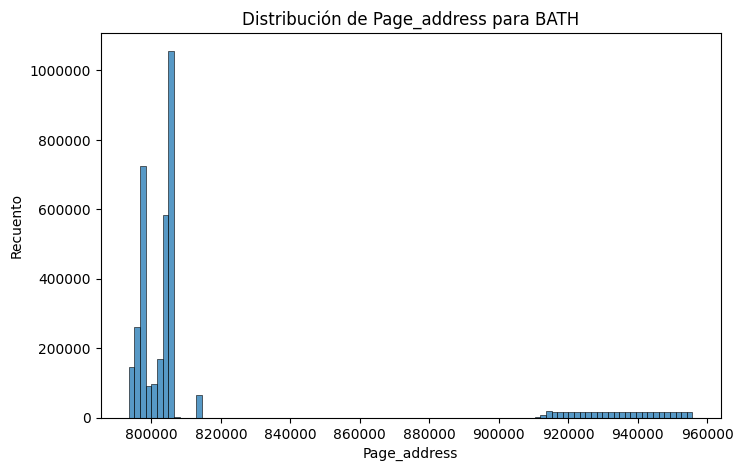

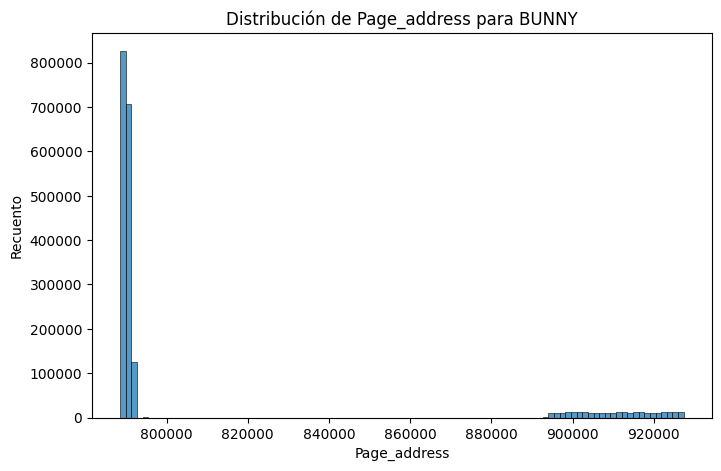

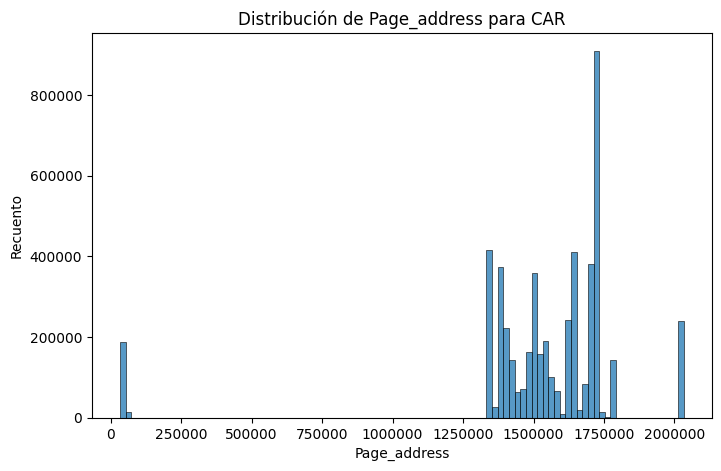

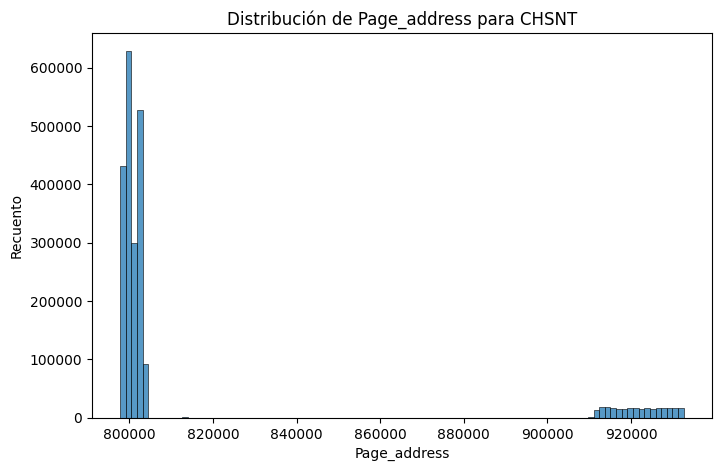

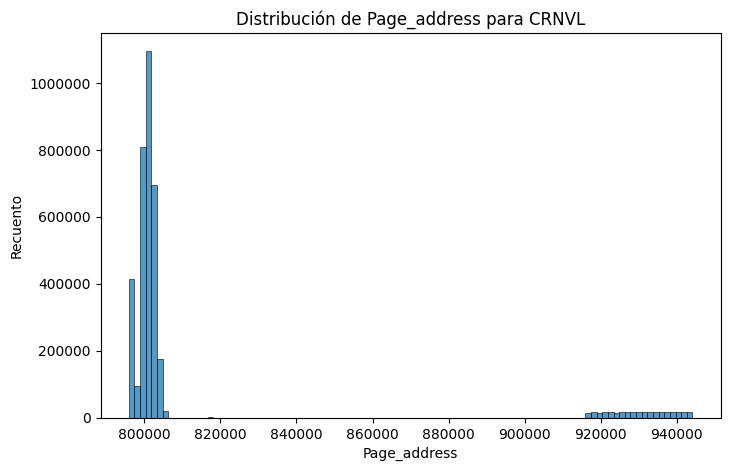

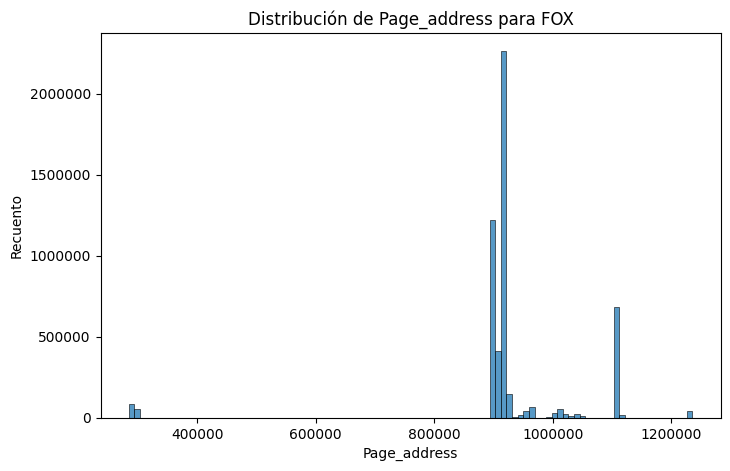

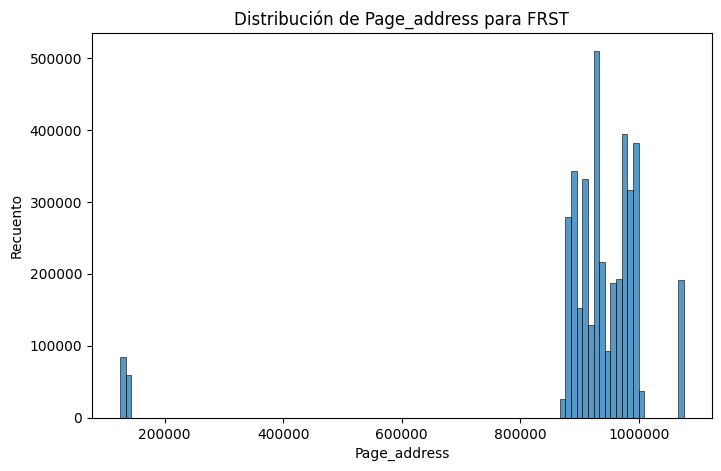

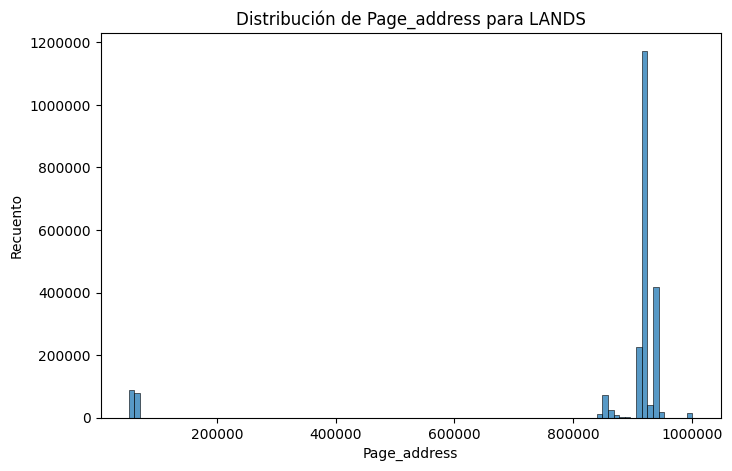

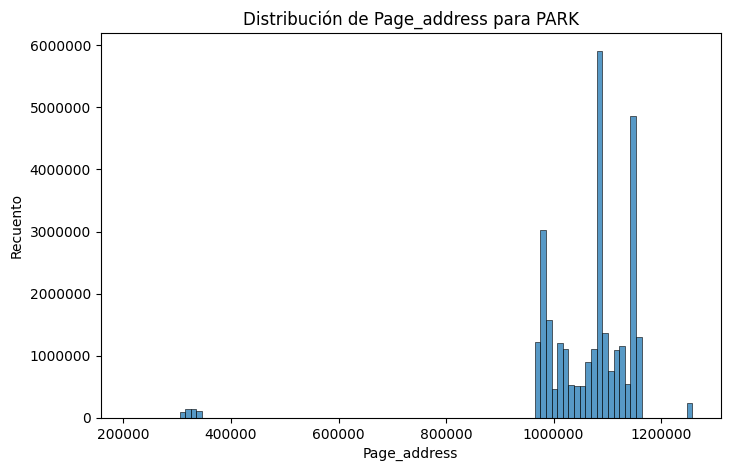

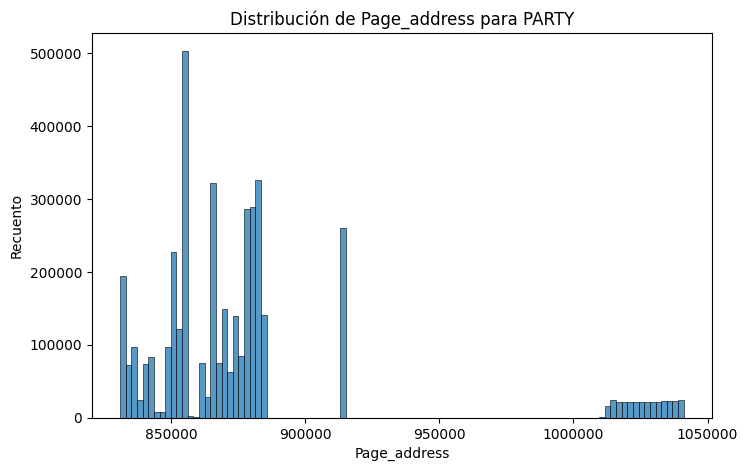

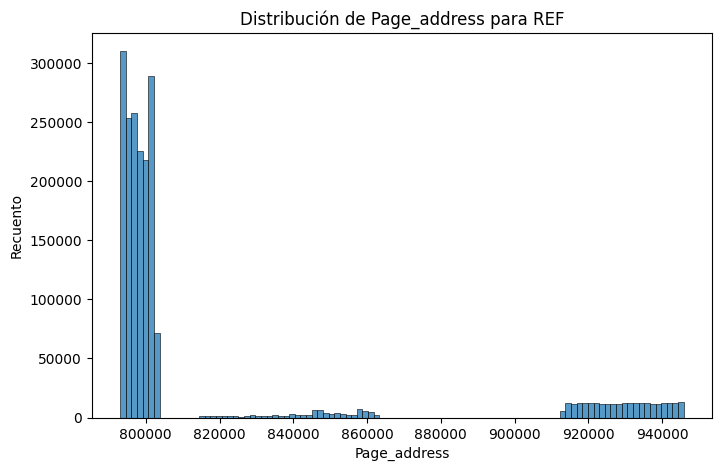

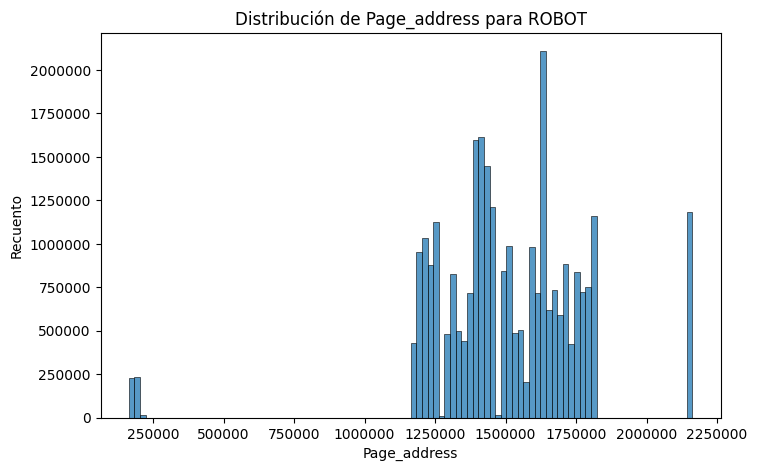

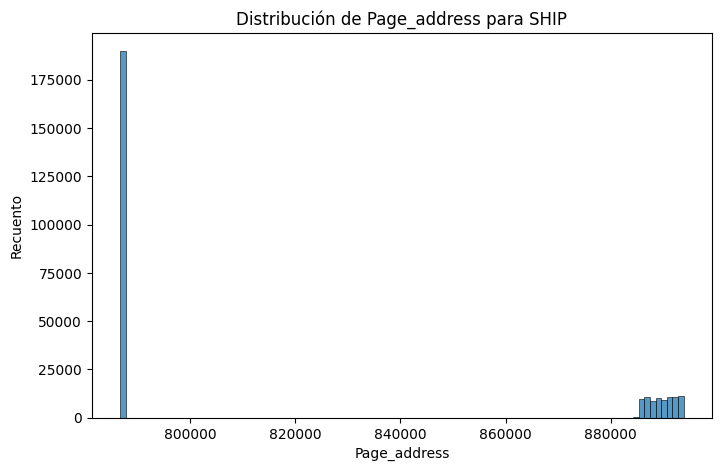

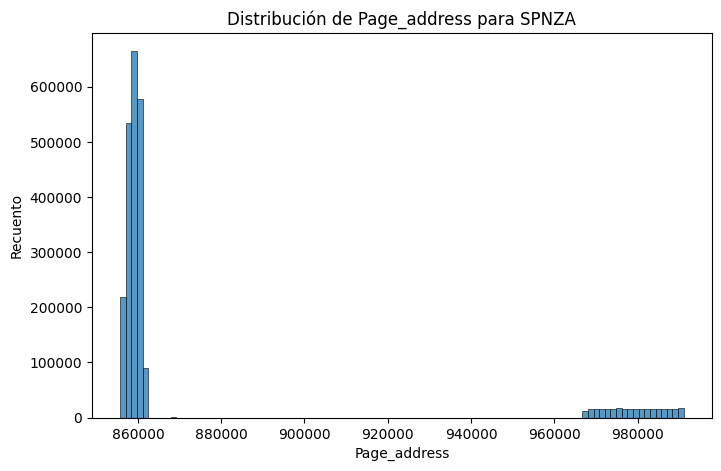

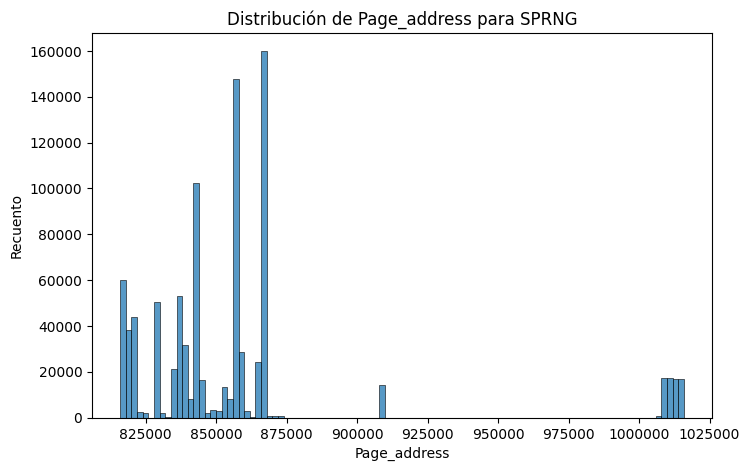

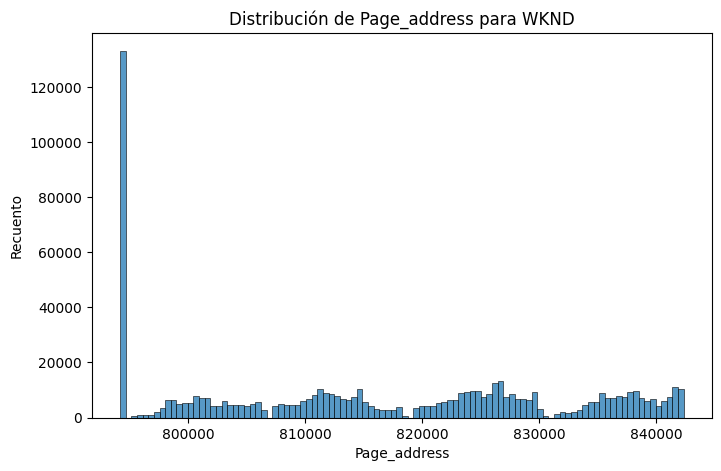

In [15]:
for escena in nombres_escenas:
    mostrar_columna(escena,"Page_address")

In [16]:
for escena in nombres_escenas:
    num_paginas_unicas = datos[escena]["Page_address"].nunique()
    print(f'Número de páginas únicas en la escena {escena}: {num_paginas_unicas} ({100*num_paginas_unicas/datos[escena]["Page_address"].count()}%)')

Número de páginas únicas en la escena BATH: 45652 (1.264966264425941%)
Número de páginas únicas en la escena BUNNY: 30779 (1.5916017784323195%)
Número de páginas únicas en la escena CAR: 85455 (1.710733065784598%)
Número de páginas únicas en la escena CHSNT: 21552 (0.9638765440160002%)
Número de páginas únicas en la escena CRNVL: 31348 (0.8699153533621806%)
Número de páginas únicas en la escena FOX: 35355 (0.6829305417819049%)
Número de páginas únicas en la escena FRST: 51638 (1.315235829593443%)
Número de páginas únicas en la escena LANDS: 25850 (1.1890343890824104%)


Número de páginas únicas en la escena PARK: 110773 (0.37153235656655176%)
Número de páginas únicas en la escena PARTY: 42100 (1.0400719206027378%)
Número de páginas únicas en la escena REF: 36469 (1.8548347310670195%)


Número de páginas únicas en la escena ROBOT: 191903 (0.6734450418129488%)
Número de páginas únicas en la escena SHIP: 6846 (2.529400680566178%)
Número de páginas únicas en la escena SPNZA: 26568 (1.1208130872899424%)
Número de páginas únicas en la escena SPRNG: 18479 (2.0299276744206485%)
Número de páginas únicas en la escena WKND: 789 (0.11521830875878193%)


In [ ]:
historias = [1,2,3,4,5,6,7,8,9,10]

# La clave es la historia. El valor es una lista con los
# porcentajes para cada escena
porcentaje_predicciones_correctas = dict()

for historia in historias:
    print(f"HISTORIA {historia}")
    print("="*20)

    porcentaje_predicciones_correctas[historia] = []

    for escena in nombres_escenas:
        ptt = dict()

        k = 5

        predicciones_correctas = 0
        predicciones_erroneas = 0

        for i in range(historia-1,len(datos[escena])-k):

            paginas_historia = tuple(datos[escena]["Page_address"][i-(historia-1):i+1])

            if paginas_historia in ptt:
                pagina_predicha = ptt[paginas_historia]
            else:
                pagina_predicha = paginas_historia[-1]

            if datos[escena]["Page_address"][i+k] == pagina_predicha:
                predicciones_correctas+=1
            else:
                predicciones_erroneas+=1

            ptt[paginas_historia] = datos[escena]["Page_address"][i+k]

        print(f"Predicciones correctas en la escena {escena}: {predicciones_correctas} ({100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas)}%)")
        porcentaje_predicciones_correctas[historia].append(100*predicciones_correctas/(predicciones_correctas+predicciones_erroneas))
    print()

HISTORIA 1


Predicciones correctas en la escena BATH: 125369 (3.4738406930557266%)


Predicciones correctas en la escena BUNNY: 104544 (5.4060510912783055%)


Predicciones correctas en la escena CAR: 373430 (7.475743820795151%)


Predicciones correctas en la escena CHSNT: 88927 (3.9771177200368877%)


...

Predicciones correctas en la escena ROBOT: 2194411 (7.700848520885815%)


Predicciones correctas en la escena SHIP: 22569 (8.339029644217659%)


Predicciones correctas en la escena SPNZA: 119616 (5.046219891259226%)


Predicciones correctas en la escena SPRNG: 42356 (4.652899988355666%)


Predicciones correctas en la escena WKND: 233042 (34.03200768721898%)



In [ ]:
with open('porcentaje_predicciones_correctas.p', 'wb') as fp:
    pickle.dump(porcentaje_predicciones_correctas, fp, protocol=pickle.HIGHEST_PROTOCOL)

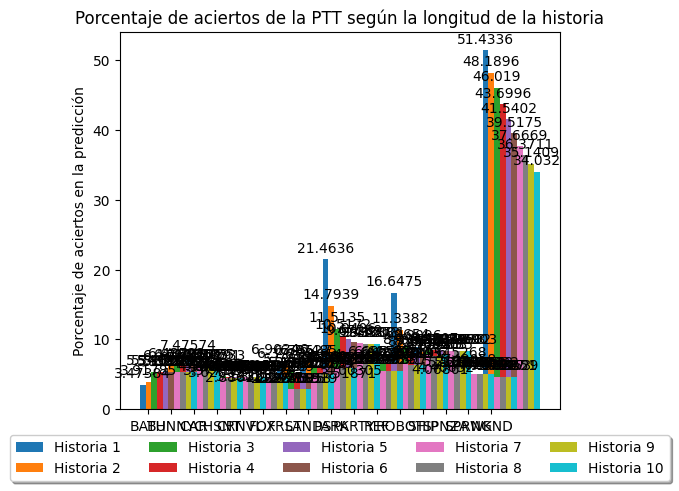

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Localización de cada etiqueta
x = np.arange(len(nombres_escenas))

# Anchura de las barras
width = 0.25

multiplier = 0

fig, ax = plt.subplots(layout='constrained')

fig.set_figwidth(25)

for historia, medidas in porcentaje_predicciones_correctas.items():
    medidas = map(float, medidas)
    offset = width * multiplier
    rects = ax.bar(x + offset, medidas, width, label=f"Historia {historia}")
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Porcentaje de aciertos en la predicción')
ax.set_title('Porcentaje de aciertos de la PTT según la longitud de la historia')
ax.set_xticks(x + width, nombres_escenas)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

plt.show()